In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
print("lib imported")

lib imported


In [3]:
image = plt.imread("/kaggle/input/data/images_001/images/00000001_000.png")
image.shape

(1024, 1024)

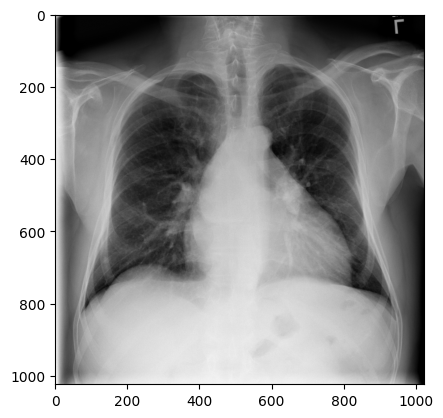

In [4]:
plt.imshow(image,cmap="gray")

In [5]:
data_label = pd.read_csv("/kaggle/input/data/Data_Entry_2017.csv")
data_label

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168,0.168,NaN
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168,0.168,NaN
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168,NaN
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168,0.168,NaN


In [6]:
print(data_label[["Image Index","Finding Labels","Patient ID"]].head)

<bound method NDFrame.head of              Image Index          Finding Labels  Patient ID
0       00000001_000.png            Cardiomegaly           1
1       00000001_001.png  Cardiomegaly|Emphysema           1
2       00000001_002.png   Cardiomegaly|Effusion           1
3       00000002_000.png              No Finding           2
4       00000003_000.png                  Hernia           3
...                  ...                     ...         ...
112115  00030801_001.png          Mass|Pneumonia       30801
112116  00030802_000.png              No Finding       30802
112117  00030803_000.png              No Finding       30803
112118  00030804_000.png              No Finding       30804
112119  00030805_000.png              No Finding       30805

[112120 rows x 3 columns]>


# Data Pre Processing 

As we can see the finding label has more than one dieseas seprated by `|` 

so lets seperate it through One - Hot Encoding using 

In [7]:
# List of all 14 diseases
all_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
              'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
              'Fibrosis', 'Pleural_Thickening', 'Hernia','No Finding']

# One-hot encode the labels
for label in all_labels:
    data_label[label] = data_label['Finding Labels'].map(lambda x: 1 if label in x else 0)

In [8]:
data_label 

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia,No Finding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,1,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168,...,0,1,0,0,0,0,0,0,0,0
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,1
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,1
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,1


lets visulize the class imbalances among all the class since it is multilabel classification 

In [9]:
import seaborn as sns 


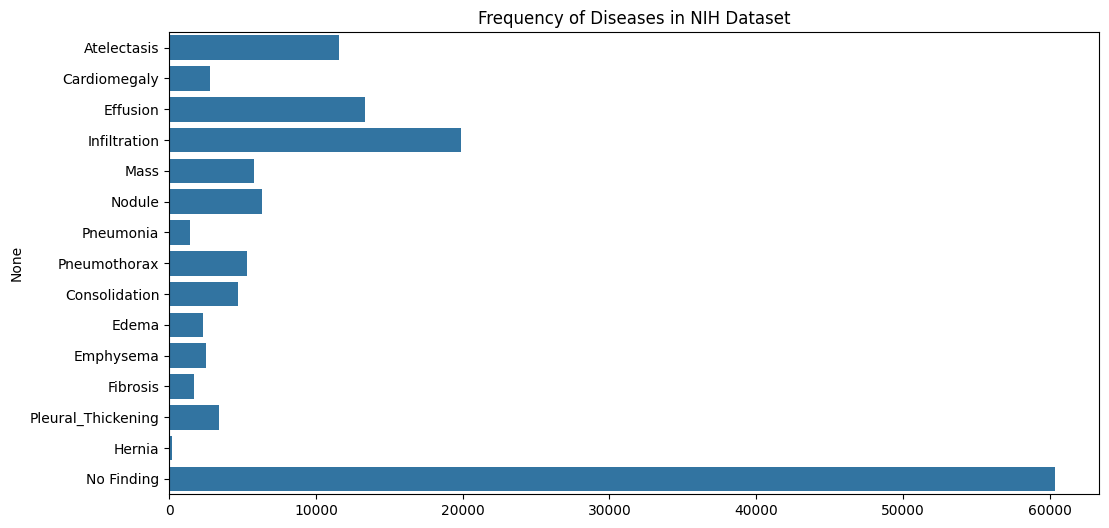

In [10]:
# Plot the distribution
# Plot the distribution
label_counts = data_label[all_labels].sum()
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.values, y=label_counts.index)
plt.title('Frequency of Diseases in NIH Dataset')
plt.show()

In [11]:
data_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
 12  Atelectasis                  112120 non-null  int64  
 13 

In [12]:
data_label.value_counts(["Unnamed: 11"])

Series([], Name: count, dtype: int64)

In [13]:
del data_label["Unnamed: 11"]

In [14]:
data_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Atelectasis                  112120 non-null  int64  
 12  Cardiomegaly                 112120 non-null  int64  
 13 

In [15]:
data_label["No Finding"].value_counts()

No Finding
1    60361
0    51759
Name: count, dtype: int64

`No Finding` means the image have no dicease means our data set have an about 60361 clean image  51759 image  is infected ones   

In [16]:
import os
from glob import glob

# Define the root path where your image folders are located
# On Kaggle, it's usually: /kaggle/input/data/
image_root_path = '/kaggle/input/data/' 

# This finds all PNGs in any subfolder under the root
all_image_paths = {os.path.basename(x): x for x in glob(os.path.join(image_root_path, 'images*', 'images', '*.png'))}

print(f"Total images found: {len(all_image_paths)}")

Total images found: 112120


In [17]:
# Create the path column
data_label['path to images'] = data_label['Image Index'].map(all_image_paths.get)

# Quick check to see if any paths are missing
missing_count = data_label['path to images'].isnull().sum()
if missing_count == 0:
    print("All images mapped successfully!")
else:
    print(f"Warning: {missing_count} images could not be found.")

All images mapped successfully!


In [18]:
data_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Atelectasis                  112120 non-null  int64  
 12  Cardiomegaly                 112120 non-null  int64  
 13 

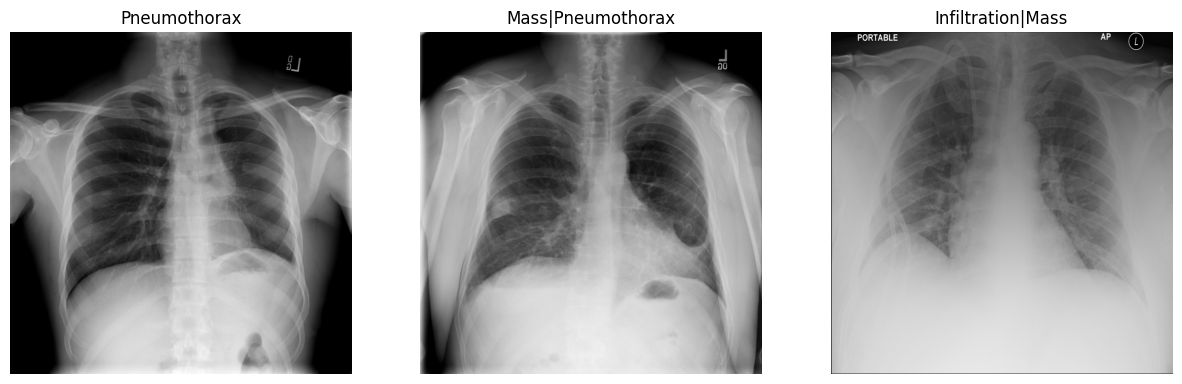

In [19]:
import matplotlib.pyplot as plt
import cv2

# Plot 3 sample images
plt.figure(figsize=(15, 5))
samples = data_label[data_label['Finding Labels'] != 'No Finding'].sample(3)

for i, (idx, row) in enumerate(samples.iterrows()):
    plt.subplot(1, 3, i+1)
    img = cv2.imread(row['path to images'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(row['Finding Labels'])
    plt.axis('off')
plt.show()